In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
import optuna
from pathlib import Path
import joblib

In [47]:
BASE_DIR = Path().resolve().parent
data_path = BASE_DIR / "data" / "mushrooms_clean.csv"
df = pd.read_csv(data_path)
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,15.26,x,g,o,f,e,unknown,w,16.95,17.09,w,t,g,d,w
1,p,16.60,x,g,o,f,e,unknown,w,17.99,18.19,w,t,g,d,u
2,p,14.07,x,g,o,f,e,unknown,w,17.80,17.74,w,t,g,d,w
3,p,14.17,f,h,e,f,e,unknown,w,15.77,15.98,w,t,p,d,w
4,p,14.64,x,h,o,f,e,unknown,w,16.53,17.20,w,t,p,d,w


In [48]:
X = df.drop('class', axis=1)
y = df['class']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features)
])

In [51]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier()
}

In [52]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

In [53]:
for name, pipe in pipelines.items():
    print(f"Entrenando {name}...")
    pipe.fit(X_train, y_train)

Entrenando LogReg...
Entrenando RandomForest...
Entrenando GradientBoosting...


In [54]:
cv_results = {}

for name, pipe in pipelines.items():

    print(f"Cross Validation: {name}")

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_results[name] = scores.mean()

# Mostrar resultados ordenados
cv_results_df = pd.DataFrame(
    cv_results.items(),
    columns=["Modelo", "F1 CV"]
)

cv_results_df["F1 CV"] = cv_results_df["F1 CV"].round(4)

cv_results_df = cv_results_df.sort_values(
    "F1 CV",
    ascending=False
)

cv_results_df

Cross Validation: LogReg
Cross Validation: RandomForest
Cross Validation: GradientBoosting


,Modelo,F1 CV
1,RandomForest,1.0000
2,GradientBoosting,0.9360
0,LogReg,0.7767


In [55]:
predictions = {}

for name, pipe in pipelines.items():
    predictions[name] = pipe.predict(X_test)

In [56]:
results = []

for name, pipe in pipelines.items():

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)

    results.append({
    "Modelo": name,
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc,
    "CV F1": cv_results[name],
    "Overfitting": train_acc - test_acc
    })

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .round(4)
    .sort_values("Test Accuracy", ascending=False)
)

results_df

,Modelo,Train Accuracy,Test Accuracy,CV F1,Overfitting
1,RandomForest,1.0000,1.0000,1.0000,0.0000
2,GradientBoosting,0.9298,0.9292,0.9360,0.0006
0,LogReg,0.7816,0.7783,0.7767,0.0033


In [60]:
def objective(trial):

    print(f"Probando trial {trial.number}...")

    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=2,
        scoring="f1_macro",
        n_jobs=-1
    ).mean()

    print(f"Trial {trial.number} terminado → F1: {score:.4f}")

    return score

In [61]:
print("Iniciando optimización con Optuna...")

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10)

print("Optimización finalizada")
print("Mejor score:", study.best_value)
print("Mejores parámetros:", study.best_params)

[I 2026-06-22 08:35:36,478] A new study created in memory with name: no-name-ce2e30b6-7098-4386-8c90-f80572f45149


Iniciando optimización con Optuna...
Probando trial 0...


[I 2026-06-22 08:35:52,589] Trial 0 finished with value: 0.8831426414058332 and parameters: {'n_estimators': 230, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8831426414058332.


Trial 0 terminado → F1: 0.8831
Probando trial 1...


[I 2026-06-22 08:36:06,991] Trial 1 finished with value: 0.9520858010094921 and parameters: {'n_estimators': 189, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.9520858010094921.


Trial 1 terminado → F1: 0.9521
Probando trial 2...


[I 2026-06-22 08:36:09,348] Trial 2 finished with value: 0.8459633830507549 and parameters: {'n_estimators': 69, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9520858010094921.


Trial 2 terminado → F1: 0.8460
Probando trial 3...


[I 2026-06-22 08:36:31,607] Trial 3 finished with value: 0.9999377243311942 and parameters: {'n_estimators': 223, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.9999377243311942.


Trial 3 terminado → F1: 0.9999
Probando trial 4...


[I 2026-06-22 08:36:54,852] Trial 4 finished with value: 0.9998131737358387 and parameters: {'n_estimators': 247, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.9999377243311942.


Trial 4 terminado → F1: 0.9998
Probando trial 5...


[I 2026-06-22 08:37:27,795] Trial 5 finished with value: 0.9998754468056374 and parameters: {'n_estimators': 291, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 3 with value: 0.9999377243311942.


Trial 5 terminado → F1: 0.9999
Probando trial 6...


[I 2026-06-22 08:37:49,402] Trial 6 finished with value: 0.9997716629289238 and parameters: {'n_estimators': 185, 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.9999377243311942.


Trial 6 terminado → F1: 0.9998
Probando trial 7...


[I 2026-06-22 08:38:11,537] Trial 7 finished with value: 0.9993772637091749 and parameters: {'n_estimators': 247, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.9999377243311942.


Trial 7 terminado → F1: 0.9994
Probando trial 8...


[I 2026-06-22 08:38:17,454] Trial 8 finished with value: 0.8415129883520465 and parameters: {'n_estimators': 245, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 3 with value: 0.9999377243311942.


Trial 8 terminado → F1: 0.8415
Probando trial 9...


[I 2026-06-22 08:38:26,043] Trial 9 finished with value: 0.9994395289812137 and parameters: {'n_estimators': 71, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.9999377243311942.


Trial 9 terminado → F1: 0.9994
Optimización finalizada
Mejor score: 0.9999377243311942
Mejores parámetros: {'n_estimators': 223, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1}


In [62]:
best_params = study.best_params

best_model = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['e','p']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cap-diameter','cap-shape','cap-surface',...,'ring-type','habitat', 'season']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [64]:
y_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      5436
           p       1.00      1.00      1.00      6749

    accuracy                           1.00     12185
   macro avg       1.00      1.00      1.00     12185
weighted avg       1.00      1.00      1.00     12185



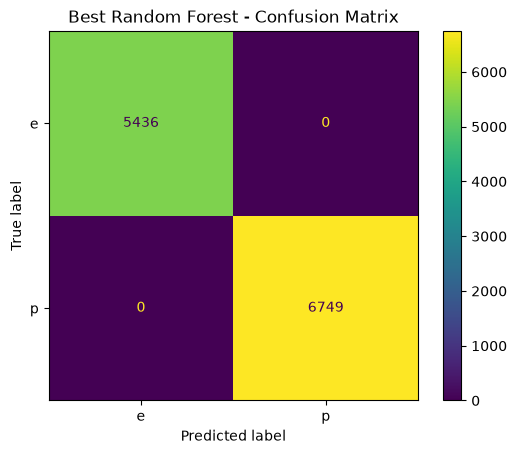

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Best Random Forest - Confusion Matrix")
plt.show()

El modelo Random Forest clasifica correctamente la totalidad de los registros del conjunto de prueba, sin observarse falsos positivos ni falsos negativos. Esto se refleja en una matriz de confusión perfecta y en métricas de precisión, recall y F1-score iguales a 1.

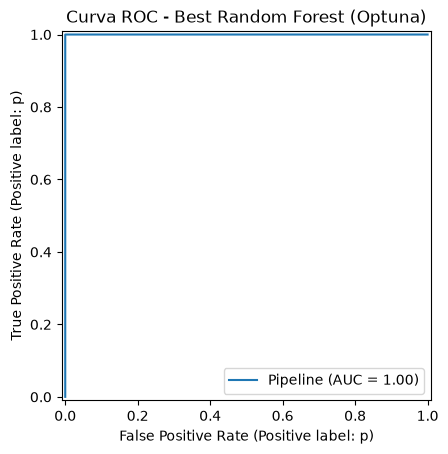

In [66]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    pos_label="p"
)

plt.title("Curva ROC - Best Random Forest (Optuna)")
plt.show()

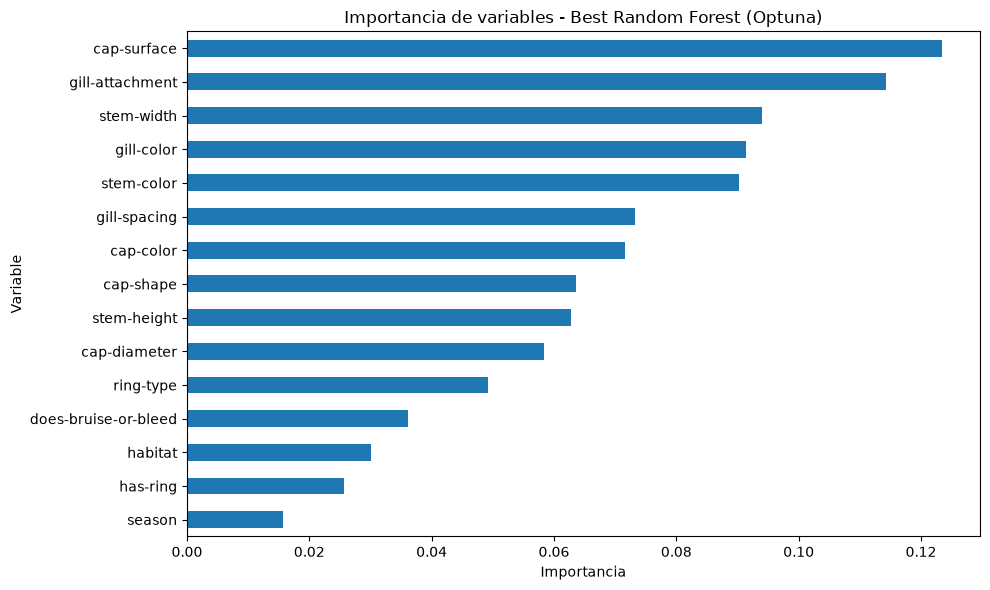

variable
cap-surface             0.123467
gill-attachment         0.114280
stem-width              0.094041
gill-color              0.091437
stem-color              0.090314
gill-spacing            0.073235
cap-color               0.071654
cap-shape               0.063583
stem-height             0.062821
cap-diameter            0.058419
ring-type               0.049134
does-bruise-or-bleed    0.036054
habitat                 0.030157
has-ring                0.025702
season                  0.015704
Name: importance, dtype: float64

In [67]:
# Extraemos el modelo entrenado
model = best_model.named_steps["model"]

# Importancias del Random Forest
importances = model.feature_importances_

# Nombres de features tras OneHotEncoding
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# DataFrame
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sacar variable original
fi_df["variable"] = (
    fi_df["feature"]
    .str.split("__").str[1]
    .str.split("_").str[0]
)

# Agrupar por variable original
fi_grouped = (
    fi_df.groupby("variable")["importance"]
    .sum()
    .sort_values(ascending=False)
)

# Gráfico
plt.figure(figsize=(10, 6))

fi_grouped.plot(kind="barh")

plt.gca().invert_yaxis()

plt.title("Importancia de variables - Best Random Forest (Optuna)")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

# Resultado en tabla
fi_grouped

In [69]:
final_model = best_model.named_steps["model"]

In [70]:
final_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 7,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 223,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [73]:
BASE_DIR = Path().resolve().parent

models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "best_random_forest_optuna.pkl"

joblib.dump(best_model, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-project-classification-Grupo-1\models\best_random_forest_optuna.pkl
